In [2]:
!pip install mediapipe==0.10.33 opencv-python

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Mery\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import urllib.request

import cv2
import numpy as np
from mediapipe.tasks.python.core.base_options import BaseOptions
from mediapipe.tasks.python.vision import (
    HandLandmarker,
    HandLandmarkerOptions,
    HandLandmarksConnections,
)
from mediapipe.tasks.python.vision.core.image import Image as MPImage
from mediapipe.tasks.python.vision.core.image import ImageFormat

# Official hand landmarker model (downloaded once)
_MODEL_URL = (
    "https://storage.googleapis.com/mediapipe-models/"
    "hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
)
_MODEL_PATH = os.path.join(
    os.path.expanduser("~"), ".cache", "mediapipe", "hand_landmarker.task"
)


def _ensure_hand_model(path: str = _MODEL_PATH) -> str:
    if not os.path.isfile(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        urllib.request.urlretrieve(_MODEL_URL, path)
    return path


from dataclasses import replace


class HandDetector:
    """Hand landmarks via MediaPipe Tasks (required on Python 3.13+ wheels)."""

    def __init__(
        self,
        max_hands=1,
        min_hand_detection_confidence=0.25,
        min_hand_presence_confidence=0.25,
        min_tracking_confidence=0.25,
    ):
        # Single-frame (IMAGE) mode is stricter than a video stream; defaults
        # like 0.7 often miss real hands. Lower all three thresholds.
        model_path = _ensure_hand_model()
        options = HandLandmarkerOptions(
            base_options=BaseOptions(model_asset_path=model_path),
            num_hands=max_hands,
            min_hand_detection_confidence=min_hand_detection_confidence,
            min_hand_presence_confidence=min_hand_presence_confidence,
            min_tracking_confidence=min_tracking_confidence,
        )
        self._landmarker = HandLandmarker.create_from_options(options)
        self._connections = HandLandmarksConnections.HAND_CONNECTIONS

    def _draw_hands(self, frame, landmarks_list):
        h, w = frame.shape[:2]
        for hand in landmarks_list:
            for conn in self._connections:
                a, b = hand[conn.start], hand[conn.end]
                if a.x is None or b.x is None:
                    continue
                cv2.line(
                    frame,
                    (int(a.x * w), int(a.y * h)),
                    (int(b.x * w), int(b.y * h)),
                    (0, 255, 0),
                    2,
                )
            for lm in hand:
                if lm.x is None:
                    continue
                cv2.circle(
                    frame, (int(lm.x * w), int(lm.y * h)), 4, (0, 0, 255), -1
                )

    def get_landmarks(self, frame):
        # MediaPipe Image expects a C-contiguous uint8 buffer; OpenCV views
        # are sometimes not contiguous, which can break inference.
        rgb = np.ascontiguousarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

        def run(arr):
            return self._landmarker.detect(MPImage(ImageFormat.SRGB, arr))

        out = run(rgb)
        if out.hand_landmarks:
            hand = out.hand_landmarks[0]
        else:
            out_m = run(np.ascontiguousarray(cv2.flip(rgb, 1)))
            if not out_m.hand_landmarks:
                return None, frame
            hand = [
                replace(lm, x=(1.0 - lm.x) if lm.x is not None else None)
                for lm in out_m.hand_landmarks[0]
            ]

        self._draw_hands(frame, [hand])

        raw = [
            (lm.x, lm.y, lm.z if lm.z is not None else 0.0) for lm in hand
        ]
        wrist_x, wrist_y, wrist_z = raw[0]
        normalized = [
            (x - wrist_x, y - wrist_y, z - wrist_z) for x, y, z in raw
        ]

        vector = np.array(normalized).flatten()
        max_val = np.max(np.abs(vector)) + 1e-6
        vector = vector / max_val

        return vector, frame


print("Ready (MediaPipe Tasks / HandLandmarker)")

Ready (MediaPipe Tasks / HandLandmarker)


In [3]:
import sys
import time

import matplotlib.pyplot as plt


def capture_frame(camera_index=0, interactive=True):
    """Grab one frame from the default webcam.

    On Windows, uses DirectShow (CAP_DSHOW) — the default backend often fails
    to open the camera from Python.

    interactive=True: opens a live window; press SPACE to freeze and capture,
    Q or ESC to cancel. If no window appears (common in some notebook hosts),
    interrupt the kernel and call capture_frame(interactive=False).

    interactive=False: no window; warms up the sensor with several reads then
    grabs one frame (webcam LED should blink briefly).
    """
    backend = cv2.CAP_DSHOW if sys.platform == "win32" else cv2.CAP_ANY

    def try_open(idx):
        c = cv2.VideoCapture(idx, backend)
        if c.isOpened():
            c.set(cv2.CAP_PROP_BUFFERSIZE, 1)
        return c

    cap = try_open(camera_index)
    if not cap.isOpened():
        for idx in (1, 2):
            cap = try_open(idx)
            if cap.isOpened():
                print(f"Using camera index {idx}")
                break

    if not cap.isOpened():
        raise RuntimeError(
            "Could not open webcam. On Windows: Settings → Privacy & security → "
            "Camera → allow desktop apps. Close Zoom/Teams using the camera. "
            "Or try capture_frame(camera_index=1, interactive=False)."
        )

    print("Camera opened — warming up…")
    for _ in range(20):
        cap.read()

    frame = None
    if interactive:
        print("Live preview: SPACE = capture, Q or ESC = cancel")
        win = "Webcam preview"
        while True:
            ret, fr = cap.read()
            if not ret:
                break
            hint = fr.copy()
            cv2.putText(
                hint,
                "SPACE capture | Q quit",
                (10, 28),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.75,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )
            cv2.imshow(win, hint)
            key = cv2.waitKey(1) & 0xFF
            if key in (27, ord("q")):
                cap.release()
                cv2.destroyAllWindows()
                raise RuntimeError("Capture cancelled")
            if key == ord(" "):
                frame = fr.copy()
                break
        cv2.destroyAllWindows()
    else:
        ret, frame = cap.read()
        if not ret:
            cap.release()
            raise RuntimeError("Failed to read frame from webcam")

    cap.release()
    cv2.destroyAllWindows()
    time.sleep(0.05)
    print("Frame captured")
    return frame


def show_frame_notebook(bgr, title="Result"):
    """Show image inside the notebook (works when cv2.imshow does not)."""
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 7))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()


print("capture_frame + show_frame_notebook ready")

capture_frame + show_frame_notebook ready


Loading detector (first run downloads ~10MB model)…
Capturing from webcam…
Camera opened — warming up…
Live preview: SPACE = capture, Q or ESC = cancel
Frame captured
Hand detected!
   Vector shape : (63,)
   First 9 values: [ 0.     0.     0.     0.155 -0.09  -0.07   0.255 -0.284 -0.081]


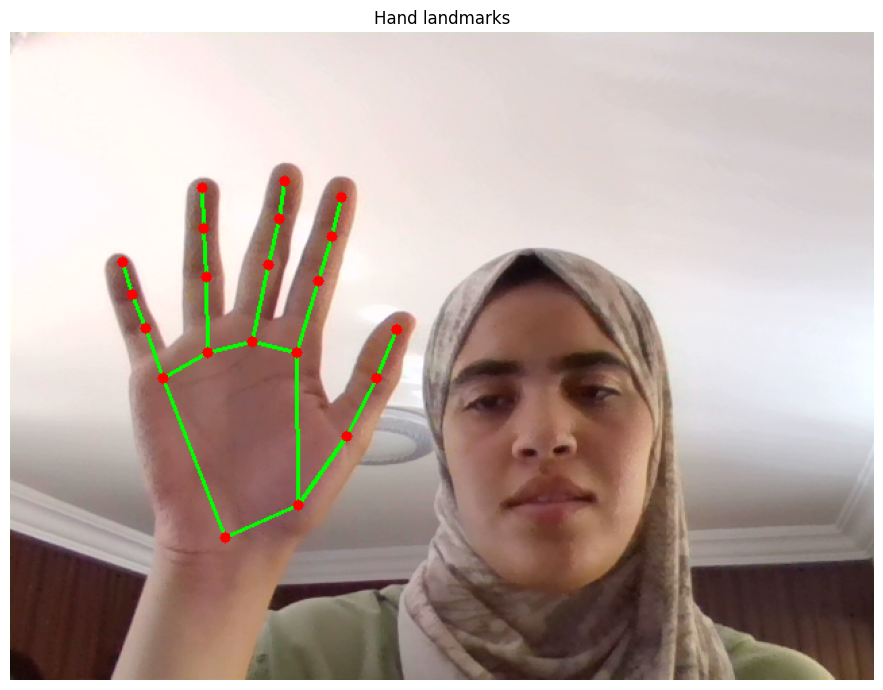

Popup window: press any key to close


In [4]:
print("Loading detector (first run downloads ~10MB model)…")
detector = HandDetector()

# interactive=True: live preview + SPACE to capture. If no window opens, use:
# frame = capture_frame(interactive=False)
print("Capturing from webcam…")
frame = capture_frame(interactive=True)

vector, annotated_frame = detector.get_landmarks(frame)

if vector is not None:
    print("Hand detected!")
    print(f"   Vector shape : {vector.shape}")
    print(f"   First 9 values: {vector[:9].round(3)}")
else:
    print("No hand detected — try better lighting or hold your hand closer")

# Always show result in the notebook (cv2.imshow often fails inside Jupyter/VS Code)
show_frame_notebook(annotated_frame, "Hand landmarks")

# Optional separate window (only if a GUI backend is available)
try:
    cv2.imshow("Hand Detector", annotated_frame)
    print("Popup window: press any key to close")
    cv2.waitKey(0)
except Exception as e:
    print("(Skipping popup window —)", e)
finally:
    cv2.destroyAllWindows()